# 01 — Data Collection

Runs the Reddit scraper and stock downloader, then does basic sanity checks on what came back.

**Run this before any other notebook.**

In [1]:
import sys
sys.path.insert(0, '../src')

import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from utils import EVENT_DATES, TICKERS

/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jamilasabazova/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


## 1a. Reddit collection

Uses Reddit's public JSON API — no credentials needed.
Expect ~10–20 minutes per event (rate-limited to 1 req/sec).
Already-collected events are skipped automatically.

In [2]:
import reddit_scraper
reddit_scraper.run_all()

2026-05-05 20:38:48,603  [teaser_trailer]  Already collected (15 posts) — delete file to re-run
2026-05-05 20:38:48,607  [full_trailer]  Already collected (26 posts) — delete file to re-run
2026-05-05 20:38:48,617  [nyc_premiere]  Already collected (91 posts) — delete file to re-run
2026-05-05 20:38:48,626  [theatrical_release]  Already collected (93 posts) — delete file to re-run
2026-05-05 20:38:48,628  [musical_previews]  Already collected (13 posts) — delete file to re-run
2026-05-05 20:38:48,631  [musical_opening]  Already collected (14 posts) — delete file to re-run
2026-05-05 20:38:48,636  [musical_extension]  Already collected (49 posts) — delete file to re-run
2026-05-05 20:38:48,638  [prada_ss26_show]  Already collected (4 posts) — delete file to re-run
2026-05-05 20:38:48,639  [prada_fw26_show]  Already collected (3 posts) — delete file to re-run


## 1b. Check Reddit data

In [3]:
reddit_dir = Path('../data/raw/reddit')

for event in EVENT_DATES:
    path = reddit_dir / f'{event}.csv'
    if path.exists():
        df = pd.read_csv(path, parse_dates=['date'])
        print(f'{event}: {len(df)} posts  |  date range: {df.date.min()} → {df.date.max()}')
        print(f'  subreddits: {df.subreddit.value_counts().to_dict()}')
        print()
    else:
        print(f'{event}: NO FILE')

teaser_trailer: 15 posts  |  date range: 2025-11-05 00:00:00 → 2025-11-18 00:00:00
  subreddits: {'movies': 7, 'boxoffice': 7, 'fashion': 1}

full_trailer: 26 posts  |  date range: 2026-01-25 00:00:00 → 2026-02-07 00:00:00
  subreddits: {'malefashionadvice': 8, 'movies': 8, 'boxoffice': 5, 'fashion': 3, 'femalefashionadvice': 1, 'westend': 1}

nyc_premiere: 91 posts  |  date range: 2026-04-13 00:00:00 → 2026-04-26 00:00:00
  subreddits: {'boxoffice': 47, 'malefashionadvice': 19, 'movies': 10, 'fashion': 7, 'femalefashionadvice': 4, 'musicals': 2, 'investing': 1, 'stocks': 1}

theatrical_release: 93 posts  |  date range: 2026-04-24 00:00:00 → 2026-05-03 00:00:00
  subreddits: {'boxoffice': 67, 'movies': 12, 'malefashionadvice': 8, 'fashion': 3, 'musicals': 2, 'westend': 1}

musical_previews: 13 posts  |  date range: 2024-10-17 00:00:00 → 2024-10-30 00:00:00
  subreddits: {'musicals': 7, 'fashion': 1, 'malefashionadvice': 1, 'movies': 1, 'boxoffice': 1, 'investing': 1, 'westend': 1}

mus

## 1c. Post volume over time (per event)

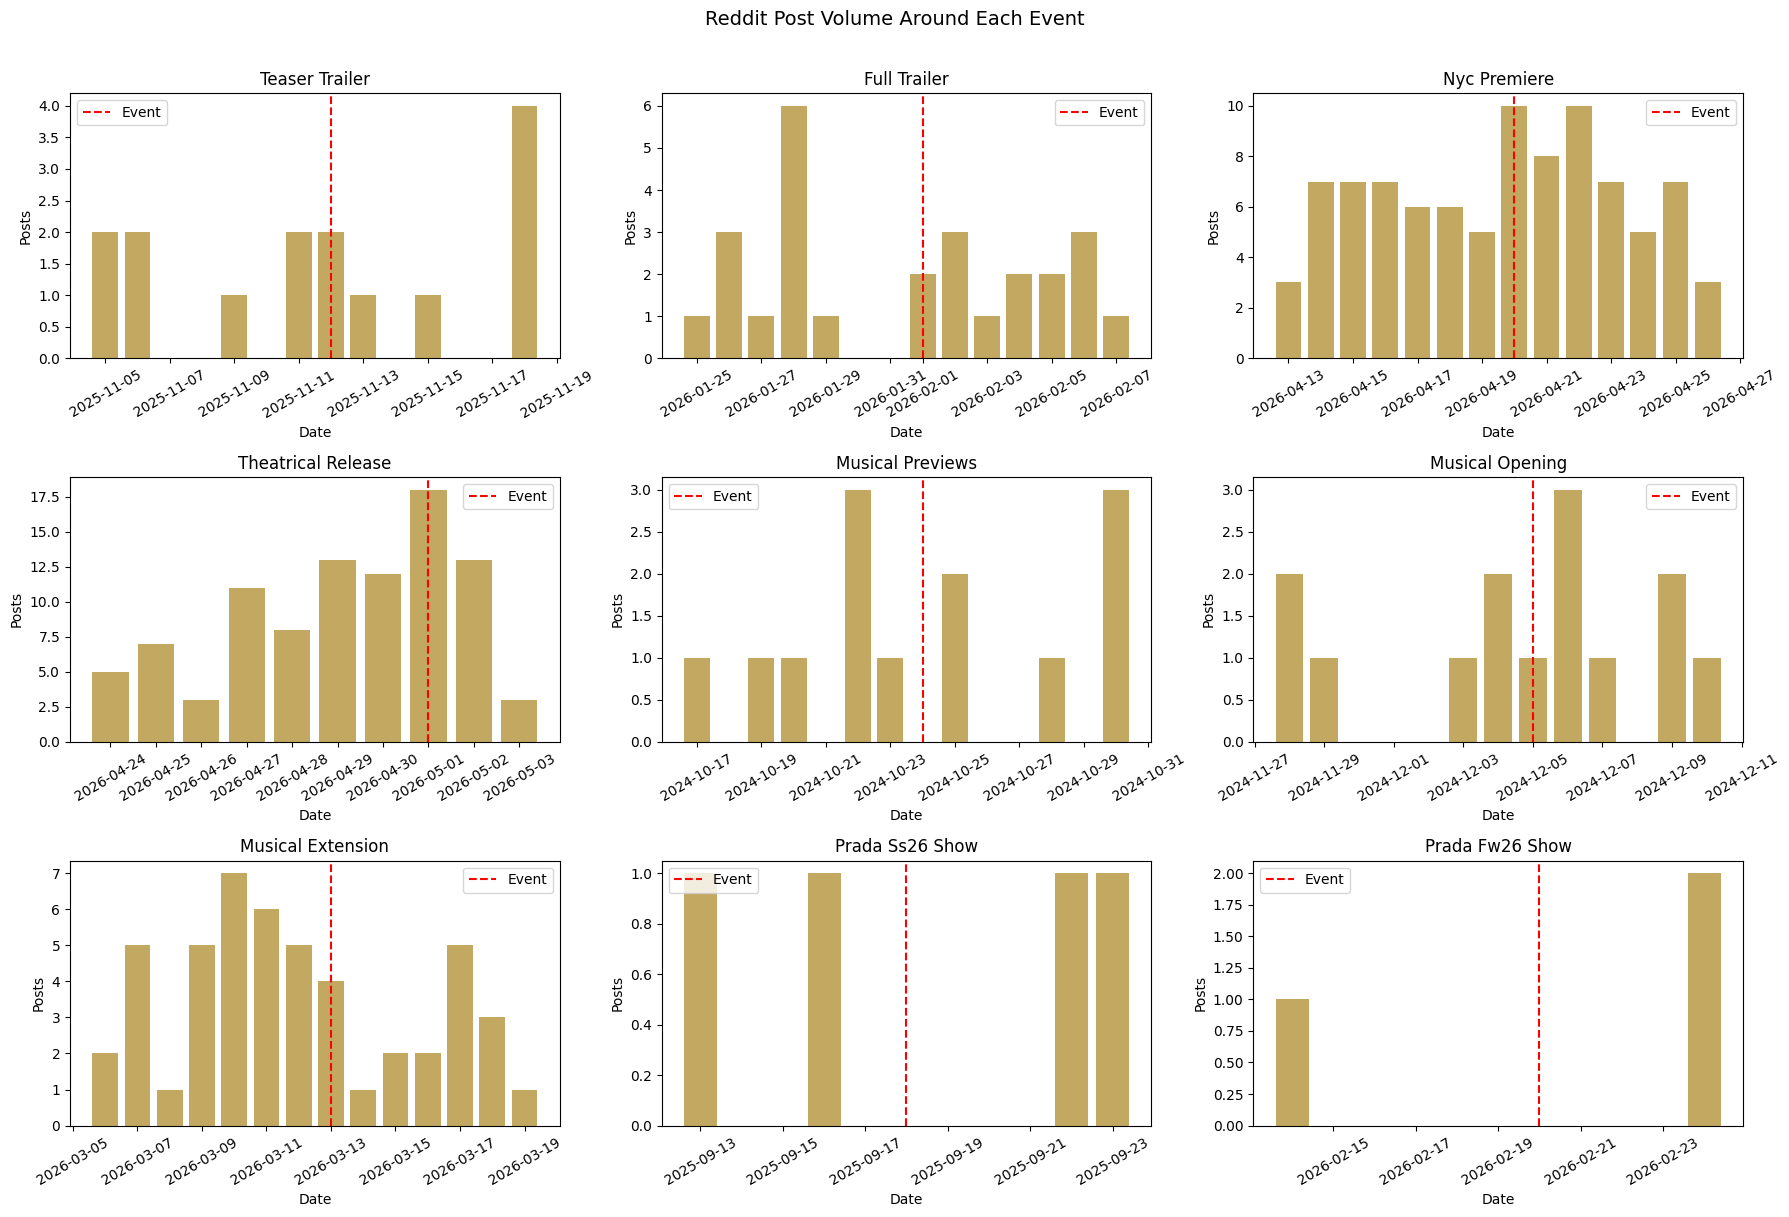

In [4]:
import math

n_events = len(EVENT_DATES)
ncols = 3
nrows = math.ceil(n_events / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 4 * nrows))
axes = axes.flatten()

for i, event in enumerate(EVENT_DATES):
    path = reddit_dir / f'{event}.csv'
    if not path.exists():
        axes[i].set_visible(False)
        continue
    df = pd.read_csv(path, parse_dates=['date'])
    daily = df.groupby('date').size()
    event_date = EVENT_DATES[event]

    axes[i].bar(daily.index, daily.values, color='#B5933A', alpha=0.8)
    axes[i].axvline(pd.Timestamp(event_date), color='red', linestyle='--', label='Event')
    axes[i].set_title(event.replace('_', ' ').title())
    axes[i].set_xlabel('Date')
    axes[i].set_ylabel('Posts')
    axes[i].legend()
    axes[i].tick_params(axis='x', rotation=30)

# Hide any unused axes
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Reddit Post Volume Around Each Event', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/post_volume.png', dpi=150, bbox_inches='tight')
plt.show()

## 1d. Stock data download

In [5]:
import stock_data
stock_data.run()

2026-05-05 20:38:51,083  Downloading 12 tickers: ['1913.HK', 'MC.PA', 'KER.PA', 'CPRI', 'TPR', 'EL', 'RMS.PA', '^HSI', '^GSPC', '^STOXX50E', 'LUXE', '^VIX']
[*********************100%***********************]  12 of 12 completed
2026-05-05 20:38:52,576  Downloaded 475 trading days, 12 tickers
2026-05-05 20:38:52,577  Date range: 2024-07-01 → 2026-05-04
2026-05-05 20:38:52,586  Prices saved to /Users/jamilasabazova/quant-projects/dwp2-luxury-sentiment/notebooks/../data/raw/stocks/prices.csv
2026-05-05 20:38:52,595  Returns saved to /Users/jamilasabazova/quant-projects/dwp2-luxury-sentiment/notebooks/../data/raw/stocks/returns.csv
2026-05-05 20:38:52,596  
Event coverage check:
2026-05-05 20:38:52,597    teaser_trailer (2025-11-12): 354 trading days before, 121 after
2026-05-05 20:38:52,597    full_trailer (2026-02-01): 410 trading days before, 65 after
2026-05-05 20:38:52,598    nyc_premiere (2026-04-20): 464 trading days before, 11 after
2026-05-05 20:38:52,599    theatrical_release (20

## 1e. Check stock data

In [6]:
prices = pd.read_csv('../data/raw/stocks/prices.csv', index_col=0, parse_dates=True)
print(f'Prices shape: {prices.shape}')
print(f'Date range: {prices.index[0].date()} → {prices.index[-1].date()}')
print(f'\nMissing values:\n{prices.isnull().sum()}')
prices.tail()

Prices shape: (475, 12)
Date range: 2024-07-01 → 2026-05-04

Missing values:
1913.HK      24
CPRI         13
EL           13
KER.PA        6
LUXE         13
MC.PA         6
RMS.PA        6
TPR          13
^GSPC        13
^HSI         24
^STOXX50E    16
^VIX         13
dtype: int64


,1913.HK,CPRI,EL,KER.PA,LUXE,MC.PA,RMS.PA,TPR,^GSPC,^HSI,^STOXX50E,^VIX
Date,,,,,,,,,,,,
2026-04-28,35.639999,19.840000,77.099998,236.100006,8.97,454.750000,1622.5,143.839996,7138.799805,25679.779297,5836.100098,17.830000
2026-04-29,35.500000,19.299999,75.690002,232.550003,8.83,448.450012,1607.5,141.600006,7135.950195,26111.839844,5816.479980,18.809999
2026-04-30,34.700001,19.510000,76.709999,232.649994,9.00,451.399994,1623.5,145.039993,7209.009766,25776.529297,5881.509766,16.889999
2026-05-01,NaN,19.629999,79.300003,NaN,9.00,NaN,NaN,142.740005,7230.120117,NaN,NaN,16.990000
2026-05-04,36.080002,18.610001,81.330002,227.250000,8.89,444.950012,1588.5,139.740005,7200.750000,26095.880859,5763.609863,18.290001
